# LLM-as-Judge Creative Quality Evaluation for Hivemind Ladder



In [1]:
!pip -q install pandas numpy matplotlib requests scipy tqdm

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
from datetime import datetime

# CHANGE THIS PATH to your actual results JSON file
RESULTS_JSON_PATH = "/content/drive/MyDrive/hivemind_ladder_results_20260510_035551/ladder_results_full.json"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"/content/drive/MyDrive/llm_judge_creative_quality_{timestamp}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Input JSON:", RESULTS_JSON_PATH)
print("Output directory:", OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input JSON: /content/drive/MyDrive/hivemind_ladder_results_20260510_035551/ladder_results_full.json
Output directory: /content/drive/MyDrive/llm_judge_creative_quality_20260511_042009


In [4]:
import os
import getpass

# Recommended: paste key interactively so it is not saved in the notebook.
if not os.environ.get("OLLAMA_API_KEY"):
    os.environ["OLLAMA_API_KEY"] = getpass.getpass("Enter your OLLAMA_API_KEY: ")

OLLAMA_HOST = "https://ollama.com"
JUDGE_MODEL = "gpt-oss:120b"

print("Using judge model:", JUDGE_MODEL)


Enter your OLLAMA_API_KEY: ··········
Using judge model: gpt-oss:120b


In [5]:
import json
from pathlib import Path

with open(RESULTS_JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

assert "responses" in data, "Expected top-level key 'responses' in the JSON file."

responses_dict = data["responses"]

num_prompts = len(responses_dict)
levels = sorted({level for prompt, level_dict in responses_dict.items() for level in level_dict.keys()})

print("Number of prompts:", num_prompts)
print("Ladder levels:", levels)

total_responses = sum(
    len(responses)
    for prompt, level_dict in responses_dict.items()
    for level, responses in level_dict.items()
)

print("Total available responses:", total_responses)


Number of prompts: 15
Ladder levels: ['L0_naive', 'L1_temperature', 'L2_adapter_only', 'L3_adapter_prompt', 'L4_fewshot', 'L5_fewshot_repulsion', 'L6_full_pipeline']
Total available responses: 3150


In [6]:
import random
import pandas as pd

MAX_RESPONSES_PER_PROMPT_PER_LEVEL = 10
SUBSAMPLE_SEED = 42

random.seed(SUBSAMPLE_SEED)

judge_items = []

for prompt, level_dict in responses_dict.items():
    for level, responses in level_dict.items():

        if not isinstance(responses, list):
            print(f"Warning: responses for prompt={prompt!r}, level={level!r} is not a list. Skipping.")
            continue

        indexed_responses = list(enumerate(responses))

        # Subsample at most 10 responses per prompt per ladder level
        if len(indexed_responses) > MAX_RESPONSES_PER_PROMPT_PER_LEVEL:
            sampled = random.sample(indexed_responses, MAX_RESPONSES_PER_PROMPT_PER_LEVEL)
        else:
            sampled = indexed_responses

        for original_response_id, response in sampled:
            judge_items.append({
                "prompt": prompt,
                "level": level,
                "original_response_id": original_response_id,
                "response": response,
                "num_available_responses": len(indexed_responses),
                "num_evaluated_for_prompt_level": len(sampled),
                "max_responses_per_prompt_per_level": MAX_RESPONSES_PER_PROMPT_PER_LEVEL,
                "subsample_seed": SUBSAMPLE_SEED,
            })

df_items = pd.DataFrame(judge_items)

print("Total selected responses for judging:", len(df_items))
display(df_items.head())

sampling_summary = (
    df_items
    .groupby(["prompt", "level"])
    .agg(
        evaluated=("response", "count"),
        available=("num_available_responses", "first")
    )
    .reset_index()
)

display(sampling_summary.head(20))

sampling_summary_path = os.path.join(OUTPUT_DIR, "sampling_summary.csv")
sampling_summary.to_csv(sampling_summary_path, index=False)
print("Saved sampling summary:", sampling_summary_path)


Total selected responses for judging: 1050


,prompt,level,original_response_id,response,num_available_responses,num_evaluated_for_prompt_level,max_responses_per_prompt_per_level,subsample_seed
0,What does home mean to you?,L0_naive,20,"Home to me is a place where I feel safe, comfo...",30,10,10,42
1,What does home mean to you?,L0_naive,3,"Home is a place where I feel safe, comfortable...",30,10,10,42
2,What does home mean to you?,L0_naive,0,"Home to me is a place where I feel safe, comfo...",30,10,10,42
3,What does home mean to you?,L0_naive,23,"Home to me is a place where I feel safe, comfo...",30,10,10,42
4,What does home mean to you?,L0_naive,8,"Home to me is a place where I feel safe, comfo...",30,10,10,42


,prompt,level,evaluated,available
0,Describe what justice looks like.,L0_naive,10,30
1,Describe what justice looks like.,L1_temperature,10,30
2,Describe what justice looks like.,L2_adapter_only,10,30
3,Describe what justice looks like.,L3_adapter_prompt,10,30
4,Describe what justice looks like.,L4_fewshot,10,30
5,Describe what justice looks like.,L5_fewshot_repulsion,10,30
6,Describe what justice looks like.,L6_full_pipeline,10,30
7,How do you know when something is true?,L0_naive,10,30
8,How do you know when something is true?,L1_temperature,10,30
9,How do you know when something is true?,L2_adapter_only,10,30


Saved sampling summary: /content/drive/MyDrive/llm_judge_creative_quality_20260511_042009/sampling_summary.csv


In [7]:
import json
import re
import time
import requests
from tqdm.auto import tqdm

def build_judge_prompt(user_prompt: str, response: str) -> str:
    return f"""
You are an expert evaluator of open-ended creative language model outputs.

Your task is to judge the response to the given user prompt.

User prompt:
{user_prompt}

Candidate response:
{response}

Evaluate the candidate response using the following 1-5 scales:

1. originality:
   1 = generic, predictable, cliché, or highly conventional
   3 = somewhat fresh but still familiar
   5 = highly original, unexpected, or distinctive

2. specificity:
   1 = vague, abstract, or empty
   3 = moderately concrete
   5 = vivid, detailed, and specific

3. expressiveness:
   1 = flat or mechanical language
   3 = adequate style
   5 = evocative, memorable, or aesthetically strong language

4. insightfulness:
   1 = shallow or obvious
   3 = somewhat thoughtful
   5 = deep, reflective, or conceptually interesting

5. coherence:
   1 = confusing, incoherent, or internally inconsistent
   3 = mostly understandable
   5 = clear, well-structured, and coherent

6. relevance:
   1 = does not answer the prompt
   3 = partially relevant
   5 = directly and meaningfully answers the prompt

7. creative_quality:
   Overall creative quality of the response, considering originality, specificity,
   expressiveness, insightfulness, coherence, and relevance.
   1 = poor creative response
   3 = acceptable creative response
   5 = excellent creative response

Return ONLY valid JSON with this exact schema:
{{
  "originality": <integer 1-5>,
  "specificity": <integer 1-5>,
  "expressiveness": <integer 1-5>,
  "insightfulness": <integer 1-5>,
  "coherence": <integer 1-5>,
  "relevance": <integer 1-5>,
  "creative_quality": <integer 1-5>,
  "brief_reason": "<one short sentence>"
}}
""".strip()


def extract_json_object(text: str) -> dict:
    text = text.strip()

    try:
        return json.loads(text)
    except Exception:
        pass

    fenced = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.DOTALL)
    if fenced:
        try:
            return json.loads(fenced.group(1))
        except Exception:
            pass

    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        candidate = text[start:end+1]
        return json.loads(candidate)

    raise ValueError(f"Could not parse JSON from model output: {text[:500]}")


def ollama_cloud_generate(prompt: str, model: str = JUDGE_MODEL, max_retries: int = 5, sleep_seconds: float = 2.0) -> str:
    api_key = os.environ["OLLAMA_API_KEY"]

    url = f"{OLLAMA_HOST}/api/generate"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }

    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.0,
            "num_predict": 512,
        },
    }

    last_error = None

    for attempt in range(max_retries):
        try:
            response = requests.post(url, headers=headers, json=payload, timeout=120)

            if response.status_code == 429:
                wait = sleep_seconds * (2 ** attempt)
                print(f"Rate limited. Sleeping for {wait:.1f}s...")
                time.sleep(wait)
                continue

            response.raise_for_status()
            result = response.json()
            return result.get("response", "")

        except Exception as e:
            last_error = e
            wait = sleep_seconds * (2 ** attempt)
            print(f"Attempt {attempt+1}/{max_retries} failed: {e}. Sleeping {wait:.1f}s...")
            time.sleep(wait)

    raise RuntimeError(f"Ollama request failed after {max_retries} attempts. Last error: {last_error}")


def judge_one_item(item: dict) -> dict:
    prompt = build_judge_prompt(item["prompt"], item["response"])
    raw = ollama_cloud_generate(prompt)
    parsed = extract_json_object(raw)

    score_fields = [
        "originality",
        "specificity",
        "expressiveness",
        "insightfulness",
        "coherence",
        "relevance",
        "creative_quality",
    ]

    out = dict(item)
    out["judge_model"] = JUDGE_MODEL
    out["judge_raw_output"] = raw

    for field in score_fields:
        value = int(parsed.get(field))
        if value < 1 or value > 5:
            raise ValueError(f"{field} out of range: {value}")
        out[field] = value

    out["brief_reason"] = str(parsed.get("brief_reason", ""))
    return out


In [8]:
import os
import pandas as pd

SCORES_CSV_PATH = os.path.join(OUTPUT_DIR, "llm_judge_creative_quality_scores.csv")
SCORES_JSON_PATH = os.path.join(OUTPUT_DIR, "llm_judge_creative_quality_scores.json")

MAX_ITEMS_TO_JUDGE = None

SAVE_EVERY = 10

items_to_judge = df_items.to_dict(orient="records")
if MAX_ITEMS_TO_JUDGE is not None:
    items_to_judge = items_to_judge[:MAX_ITEMS_TO_JUDGE]


completed_keys = set()
results = []

if os.path.exists(SCORES_CSV_PATH):
    existing = pd.read_csv(SCORES_CSV_PATH)
    results = existing.to_dict(orient="records")
    completed_keys = set(
        zip(
            existing["prompt"],
            existing["level"],
            existing["original_response_id"],
        )
    )
    print(f"Resuming from existing file with {len(results)} completed judgments.")

for idx, item in enumerate(tqdm(items_to_judge, desc="Judging responses")):
    key = (item["prompt"], item["level"], item["original_response_id"])

    if key in completed_keys:
        continue

    try:
        judged = judge_one_item(item)
        judged["judge_error"] = ""
    except Exception as e:
        judged = dict(item)
        judged["judge_model"] = JUDGE_MODEL
        judged["judge_raw_output"] = ""
        judged["originality"] = None
        judged["specificity"] = None
        judged["expressiveness"] = None
        judged["insightfulness"] = None
        judged["coherence"] = None
        judged["relevance"] = None
        judged["creative_quality"] = None
        judged["brief_reason"] = ""
        judged["judge_error"] = str(e)

    results.append(judged)
    completed_keys.add(key)

    if len(results) % SAVE_EVERY == 0:
        df_scores = pd.DataFrame(results)
        df_scores.to_csv(SCORES_CSV_PATH, index=False)
        df_scores.to_json(SCORES_JSON_PATH, orient="records", indent=2, force_ascii=False)
        print(f"Saved progress after {len(results)} judgments.")

df_scores = pd.DataFrame(results)
df_scores.to_csv(SCORES_CSV_PATH, index=False)
df_scores.to_json(SCORES_JSON_PATH, orient="records", indent=2, force_ascii=False)

print("Saved final scores:")
print(SCORES_CSV_PATH)
print(SCORES_JSON_PATH)

display(df_scores.head())
print("Number of successful judgments:", df_scores["creative_quality"].notna().sum())
print("Number of failed judgments:", df_scores["creative_quality"].isna().sum())


Judging responses:   0%|          | 0/1050 [00:00<?, ?it/s]

Saved progress after 10 judgments.
Saved progress after 20 judgments.
Saved progress after 30 judgments.
Saved progress after 40 judgments.
Saved progress after 50 judgments.
Saved progress after 60 judgments.
Saved progress after 70 judgments.
Saved progress after 80 judgments.
Saved progress after 90 judgments.
Saved progress after 100 judgments.
Saved progress after 110 judgments.
Saved progress after 120 judgments.
Saved progress after 130 judgments.
Saved progress after 140 judgments.
Saved progress after 150 judgments.
Saved progress after 160 judgments.
Saved progress after 170 judgments.
Saved progress after 180 judgments.
Saved progress after 190 judgments.
Saved progress after 200 judgments.
Saved progress after 210 judgments.
Saved progress after 220 judgments.
Saved progress after 230 judgments.
Saved progress after 240 judgments.
Saved progress after 250 judgments.
Saved progress after 260 judgments.
Saved progress after 270 judgments.
Saved progress after 280 judgments.
S

,prompt,level,original_response_id,response,num_available_responses,num_evaluated_for_prompt_level,max_responses_per_prompt_per_level,subsample_seed,judge_model,judge_raw_output,originality,specificity,expressiveness,insightfulness,coherence,relevance,creative_quality,brief_reason,judge_error
0,What does home mean to you?,L0_naive,20,"Home to me is a place where I feel safe, comfo...",30,10,10,42,gpt-oss:120b,"{\n ""originality"": 2,\n ""specificity"": 3,\n ...",2.0,3.0,2.0,2.0,5.0,5.0,3.0,The response is clear and relevant but mostly ...,
1,What does home mean to you?,L0_naive,3,"Home is a place where I feel safe, comfortable...",30,10,10,42,gpt-oss:120b,"{\n ""originality"": 2,\n ""specificity"": 2,\n ...",2.0,2.0,2.0,2.0,5.0,5.0,2.0,The response is clear and on‑topic but uses ge...,
2,What does home mean to you?,L0_naive,0,"Home to me is a place where I feel safe, comfo...",30,10,10,42,gpt-oss:120b,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,"Could not parse JSON from model output: {\n ""..."
3,What does home mean to you?,L0_naive,23,"Home to me is a place where I feel safe, comfo...",30,10,10,42,gpt-oss:120b,"{\n ""originality"": 2,\n ""specificity"": 2,\n ...",2.0,2.0,2.0,2.0,5.0,5.0,2.0,The response clearly addresses the prompt but ...,
4,What does home mean to you?,L0_naive,8,"Home to me is a place where I feel safe, comfo...",30,10,10,42,gpt-oss:120b,"{\n ""originality"": 2,\n ""specificity"": 2,\n ...",2.0,2.0,3.0,2.0,5.0,5.0,3.0,The answer is clear and relevant but largely g...,


Number of successful judgments: 862
Number of failed judgments: 188


In [9]:
import numpy as np

df_valid = df_scores.dropna(subset=["creative_quality"]).copy()

score_cols = [
    "originality",
    "specificity",
    "expressiveness",
    "insightfulness",
    "coherence",
    "relevance",
    "creative_quality",
]

summary = (
    df_valid
    .groupby("level")[score_cols]
    .agg(["mean", "std", "count"])
)


summary.columns = ["_".join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()

summary["creative_quality_se"] = (
    summary["creative_quality_std"] / np.sqrt(summary["creative_quality_count"])
)

summary_path = os.path.join(OUTPUT_DIR, "llm_judge_ladder_summary.csv")
summary.to_csv(summary_path, index=False)

print("Saved summary:", summary_path)
display(summary)


Saved summary: /content/drive/MyDrive/llm_judge_creative_quality_20260511_042009/llm_judge_ladder_summary.csv


,level,originality_mean,originality_std,originality_count,specificity_mean,specificity_std,specificity_count,expressiveness_mean,expressiveness_std,expressiveness_count,...,coherence_mean,coherence_std,coherence_count,relevance_mean,relevance_std,relevance_count,creative_quality_mean,creative_quality_std,creative_quality_count,creative_quality_se
0,L0_naive,1.864286,0.343715,140,2.250000,0.564221,140,2.071429,0.309161,140,...,3.400000,1.210268,140,4.464286,0.703646,140,2.342857,0.476369,140,0.040260
1,L1_temperature,1.818182,0.387050,143,2.265734,0.556030,143,2.118881,0.345790,143,...,3.384615,1.272256,143,4.321678,0.801420,143,2.377622,0.486496,143,0.040683
2,L2_adapter_only,1.751825,0.433539,137,2.226277,0.581488,137,2.094891,0.381237,137,...,3.583942,1.222596,137,4.481752,0.708169,137,2.328467,0.471379,137,0.040273
3,L3_adapter_prompt,3.036496,0.789720,137,2.941606,0.565769,137,2.722628,0.465421,137,...,3.890511,1.161128,137,4.386861,0.868130,137,3.102190,0.597601,137,0.051057
4,L4_fewshot,3.470149,0.633528,134,3.559701,0.631399,134,3.455224,0.595922,134,...,4.149254,0.945965,134,4.776119,0.557138,134,3.619403,0.559199,134,0.048307
5,L5_fewshot_repulsion,3.410256,0.653381,78,3.551282,0.677034,78,3.282051,0.662491,78,...,3.410256,0.999167,78,4.448718,0.831950,78,3.435897,0.675926,78,0.076534
6,L6_full_pipeline,3.268817,0.693758,93,3.473118,0.652610,93,3.161290,0.647576,93,...,3.064516,1.008728,93,4.344086,0.878420,93,3.247312,0.686135,93,0.071149


In [10]:
per_prompt_summary = (
    df_valid
    .groupby(["prompt", "level"])[score_cols]
    .agg(["mean", "std", "count"])
)

per_prompt_summary.columns = ["_".join(col).strip() for col in per_prompt_summary.columns.values]
per_prompt_summary = per_prompt_summary.reset_index()

per_prompt_summary_path = os.path.join(OUTPUT_DIR, "llm_judge_per_prompt_summary.csv")
per_prompt_summary.to_csv(per_prompt_summary_path, index=False)

print("Saved per-prompt summary:", per_prompt_summary_path)
display(per_prompt_summary.head(30))


Saved per-prompt summary: /content/drive/MyDrive/llm_judge_creative_quality_20260511_042009/llm_judge_per_prompt_summary.csv


,prompt,level,originality_mean,originality_std,originality_count,specificity_mean,specificity_std,specificity_count,expressiveness_mean,expressiveness_std,...,insightfulness_count,coherence_mean,coherence_std,coherence_count,relevance_mean,relevance_std,relevance_count,creative_quality_mean,creative_quality_std,creative_quality_count
0,Describe what justice looks like.,L0_naive,2.000000,0.000000,9,2.222222,0.440959,9,2.111111,0.333333,...,9,3.111111,1.054093,9,4.222222,0.666667,9,2.111111,0.333333,9
1,Describe what justice looks like.,L1_temperature,1.900000,0.316228,10,2.000000,0.000000,10,2.000000,0.000000,...,10,2.700000,1.251666,10,3.600000,0.699206,10,2.000000,0.000000,10
2,Describe what justice looks like.,L2_adapter_only,1.500000,0.534522,8,2.500000,0.755929,8,2.000000,0.534522,...,8,3.375000,1.407886,8,4.125000,0.834523,8,2.125000,0.353553,8
3,Describe what justice looks like.,L3_adapter_prompt,3.142857,1.069045,7,3.285714,0.487950,7,2.571429,0.534522,...,7,3.428571,1.133893,7,4.000000,0.816497,7,3.000000,0.577350,7
4,Describe what justice looks like.,L4_fewshot,3.875000,0.640870,8,3.875000,0.834523,8,3.750000,0.886405,...,8,4.500000,0.755929,8,4.875000,0.353553,8,4.000000,0.755929,8
5,Describe what justice looks like.,L5_fewshot_repulsion,4.166667,0.408248,6,3.333333,0.516398,6,3.666667,0.816497,...,6,3.666667,1.211060,6,4.833333,0.408248,6,3.666667,0.816497,6
6,Describe what justice looks like.,L6_full_pipeline,3.500000,0.836660,6,3.666667,0.516398,6,3.333333,0.516398,...,6,3.000000,0.632456,6,5.000000,0.000000,6,3.500000,0.547723,6
7,How do you know when something is true?,L0_naive,1.666667,0.500000,9,2.888889,0.333333,9,2.000000,0.000000,...,9,3.666667,1.118034,9,4.666667,0.500000,9,2.666667,0.500000,9
8,How do you know when something is true?,L1_temperature,1.800000,0.421637,10,3.000000,0.000000,10,2.100000,0.316228,...,10,4.200000,1.032796,10,4.900000,0.316228,10,3.000000,0.000000,10
9,How do you know when something is true?,L2_adapter_only,1.666667,0.500000,9,2.888889,0.333333,9,2.000000,0.000000,...,9,3.000000,1.118034,9,4.666667,0.500000,9,2.444444,0.527046,9


In [11]:
from scipy.stats import ttest_rel, wilcoxon

BASELINE_LEVEL = "L0"

prompt_level_means = (
    df_valid
    .groupby(["prompt", "level"])["creative_quality"]
    .mean()
    .reset_index()
)

available_levels = sorted(prompt_level_means["level"].unique())
print("Available levels:", available_levels)

if BASELINE_LEVEL not in available_levels:
    print(f"WARNING: BASELINE_LEVEL={BASELINE_LEVEL!r} not found.")
    print("Set BASELINE_LEVEL to one of the available levels and rerun this cell.")
else:
    baseline = (
        prompt_level_means[prompt_level_means["level"] == BASELINE_LEVEL]
        [["prompt", "creative_quality"]]
        .rename(columns={"creative_quality": "baseline_creative_quality"})
    )

    test_rows = []

    for level in available_levels:
        if level == BASELINE_LEVEL:
            continue

        current = (
            prompt_level_means[prompt_level_means["level"] == level]
            [["prompt", "creative_quality"]]
            .rename(columns={"creative_quality": "level_creative_quality"})
        )

        paired = baseline.merge(current, on="prompt", how="inner")
        diffs = paired["level_creative_quality"] - paired["baseline_creative_quality"]

        if len(paired) >= 2:
            t_stat, t_p = ttest_rel(
                paired["level_creative_quality"],
                paired["baseline_creative_quality"]
            )
            try:
                w_stat, w_p = wilcoxon(diffs)
            except Exception:
                w_stat, w_p = np.nan, np.nan
        else:
            t_stat, t_p, w_stat, w_p = np.nan, np.nan, np.nan, np.nan

        test_rows.append({
            "baseline_level": BASELINE_LEVEL,
            "comparison_level": level,
            "num_paired_prompts": len(paired),
            "mean_baseline": paired["baseline_creative_quality"].mean(),
            "mean_level": paired["level_creative_quality"].mean(),
            "mean_difference": diffs.mean(),
            "paired_t_stat": t_stat,
            "paired_t_p": t_p,
            "wilcoxon_stat": w_stat,
            "wilcoxon_p": w_p,
        })

    df_tests = pd.DataFrame(test_rows)
    tests_path = os.path.join(OUTPUT_DIR, "llm_judge_paired_tests_vs_baseline.csv")
    df_tests.to_csv(tests_path, index=False)

    print("Saved paired tests:", tests_path)
    display(df_tests)


Available levels: ['L0_naive', 'L1_temperature', 'L2_adapter_only', 'L3_adapter_prompt', 'L4_fewshot', 'L5_fewshot_repulsion', 'L6_full_pipeline']
Set BASELINE_LEVEL to one of the available levels and rerun this cell.


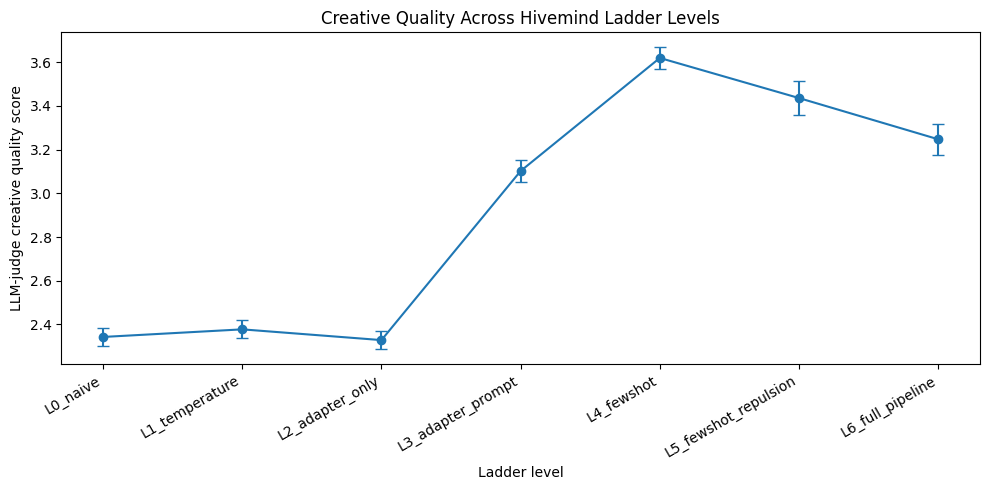

Saved figure: /content/drive/MyDrive/llm_judge_creative_quality_20260511_042009/fig_llm_judge_creative_quality_by_level.png


In [12]:
import matplotlib.pyplot as plt

plot_df = summary.copy()

def level_sort_key(x):
    x_str = str(x)
    digits = ''.join(ch for ch in x_str if ch.isdigit())
    return int(digits) if digits else x_str

plot_df = plot_df.sort_values("level", key=lambda s: s.map(level_sort_key))

plt.figure(figsize=(10, 5))
plt.errorbar(
    plot_df["level"].astype(str),
    plot_df["creative_quality_mean"],
    yerr=plot_df["creative_quality_se"],
    marker="o",
    capsize=4,
)
plt.xlabel("Ladder level")
plt.ylabel("LLM-judge creative quality score")
plt.title("Creative Quality Across Hivemind Ladder Levels")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "fig_llm_judge_creative_quality_by_level.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved figure:", fig_path)


In [13]:
top_examples = (
    df_valid
    .sort_values("creative_quality", ascending=False)
    [["prompt", "level", "original_response_id", "creative_quality", "brief_reason", "response"]]
    .head(10)
)

display(top_examples)

low_examples = (
    df_valid
    .sort_values("creative_quality", ascending=True)
    [["prompt", "level", "original_response_id", "creative_quality", "brief_reason", "response"]]
    .head(10)
)

display(low_examples)


,prompt,level,original_response_id,creative_quality,brief_reason,response
52,What does home mean to you?,L5_fewshot_repulsion,25,5.0,"A vivid, culturally rich answer that clearly a...",[Filipino perspective]:home for me symbolizes ...
321,Describe what justice looks like.,L4_fewshot,6,5.0,"Provides a vivid, culturally specific, and evo...",perspective not already represented above. Be ...
331,Describe what justice looks like.,L5_fewshot_repulsion,25,5.0,"A vivid, culturally specific, well‑written des...",Draw from a perspective not already represente...
743,What obligations do we owe to future generations?,L4_fewshot,24,5.0,"Offers a vivid, culturally distinct and emotiv...",[/INST] [Indigenous Australian Aboriginal pers...
624,What role should elders play in society?,L6_full_pipeline,21,5.0,"Clear, evocative Aboriginal perspective detail...",not already represented above. Be authentic an...
670,How do you know when something is true?,L4_fewshot,25,5.0,"The response offers a vivid, coherent, and ori...",[/INST] [Indigenous Amazonian perspective]: In...
209,What is the purpose of suffering?,L6_full_pipeline,18,5.0,"Provides a distinctive, concrete cultural pers...",] [Melanesian Papua New Guinean perspective]: ...
323,Describe what justice looks like.,L4_fewshot,12,5.0,"The response offers a vivid, culturally specif...",perspective not already represented above. Be ...
1017,What makes a life meaningful?,L3_adapter_prompt,10,4.0,Offers a thoughtful Ubuntu perspective on mean...,"In Sub-Saharan African communal traditions, pa..."
1014,What makes a life meaningful?,L3_adapter_prompt,15,4.0,"Provides a clear, culturally specific answer a...","In Sub-Saharan African communal traditions, pa..."


,prompt,level,original_response_id,creative_quality,brief_reason,response
26,What does home mean to you?,L2_adapter_only,28,2.0,The answer is clear and on-topic but relies on...,"Home to me is a place of comfort, safety, and ..."
23,What does home mean to you?,L2_adapter_only,22,2.0,The response is clear and on‑topic but relies ...,"Home to me is a place where I feel safe, comfo..."
22,What does home mean to you?,L2_adapter_only,6,2.0,"The response is generic and vague, offering no...",Home to me is a place where I feel a deep sens...
21,What does home mean to you?,L2_adapter_only,17,2.0,The answer is clear and on-topic but very gene...,Home is a place where I feel a strong sense of...
20,What does home mean to you?,L2_adapter_only,0,2.0,"The answer is clear and on‑topic but generic, ...","Home to me is a place where I feel safe, comfo..."
37,What does home mean to you?,L3_adapter_prompt,13,2.0,The response offers a generic cultural view ra...,From a North American frontier individualistic...
14,What does home mean to you?,L1_temperature,0,2.0,"The response is generic and vague, offering li...","Home to me is a place where I feel safe, comfo..."
13,What does home mean to you?,L1_temperature,1,2.0,"The answer is clear and relevant but generic, ...","Home to me is a place of comfort, safety, and ..."
10,What does home mean to you?,L1_temperature,2,2.0,"The answer is generic, vague, and lacks vivid ...","Home to me is a place where I feel safe, comfo..."
7,What does home mean to you?,L0_naive,4,2.0,"The response is generic and vague, though clea...","Home to me is a place where I feel safe, comfo..."
